In [31]:
from glob import glob


In [32]:
classes = glob('Train/Full moon/*')
print(classes)

['Train/Full moon\\alexander-andrews-H0dcpcO_hYc-unsplash.jpg', 'Train/Full moon\\alexander-andrews-vGCErDhrc3E-unsplash.jpg', 'Train/Full moon\\alexis-antonio-TFth26tEjss-unsplash.jpg', 'Train/Full moon\\aron-visuals-4zxSWESyZio-unsplash.jpg', 'Train/Full moon\\aron-visuals-aH_9n6Ly3Jc-unsplash.jpg', 'Train/Full moon\\aron-visuals-DdoXpQXobQs-unsplash.jpg', 'Train/Full moon\\aryan-sur-I6_HFcD74-E-unsplash.jpg', 'Train/Full moon\\benjamin-child-6msS8vT5pzw-unsplash.jpg', 'Train/Full moon\\chuttersnap-h3GIogY6LL4-unsplash.jpg', 'Train/Full moon\\chuttersnap-hJNNvvHo3zw-unsplash.jpg', 'Train/Full moon\\chuttersnap-pE8WW245aik-unsplash.jpg', 'Train/Full moon\\cristofer-maximilian-IgX2o2_xAZc-unsplash.jpg', 'Train/Full moon\\cristofer-maximilian-nW3Zc0xHEGg-unsplash.jpg', 'Train/Full moon\\daniil-silantev-OD_yYNIes74-unsplash.jpg', 'Train/Full moon\\david-dibert-Na0BbqKbfAo-unsplash.jpg', 'Train/Full moon\\edvin-karlsson-yfCLVvjgMmQ-unsplash.jpg', 'Train/Full moon\\erik-mclean-0PtTH5HwmVQ-

In [33]:
import os
print(os.getcwd())

e:\Deb\Moon CNN


In [34]:
from PIL import Image

file_path='Train/Full moon'
for img_name in os.listdir(file_path):
    img=Image.open(os.path.join(file_path,img_name))
    sizes=(set(img.size))


c:\Users\Debomoy Patra\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (99440784 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [35]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    'Train',
    image_size=(128, 128),
    batch_size=32,
    color_mode='grayscale',
    label_mode='int',
    shuffle=True
)

val_dataset = image_dataset_from_directory(
    'Test',
    image_size=(128, 128),
    batch_size=32,
    color_mode='grayscale',
    label_mode='int',
    shuffle=False
)

Found 248 files belonging to 4 classes.
Found 58 files belonging to 4 classes.


In [36]:
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Resizing(140, 140),

    tf.keras.layers.CenterCrop(128, 128),

    tf.keras.layers.RandomRotation(1.0),

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomBrightness(factor=0.2),

    tf.keras.layers.Rescaling(1./127.5, offset=-1)
])

In [37]:
import tensorflow as tf



In [38]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 1)),
    data_augmentation,
    tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(units=128, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')

    ])  


In [39]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,700 (428.52 KB)

 Trainable params: 109,700 (428.52 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.2298 - loss: 1.3959 - val_accuracy: 0.3966 - val_loss: 1.3806
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.3831 - loss: 1.3783 - val_accuracy: 0.3966 - val_loss: 1.3632
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.3629 - loss: 1.3610 - val_accuracy: 0.4138 - val_loss: 1.3374
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - accuracy: 0.3992 - loss: 1.3422 - val_accuracy: 0.3966 - val_loss: 1.2889
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.3669 - loss: 1.3178 - val_accuracy: 0.3621 - val_loss: 1.2646
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 179ms/step - accuracy: 0.3629 - loss: 1.3204 - val_accuracy: 0.3276 - val_loss: 1.2597
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.3669 - loss: 1.3006 - val_accuracy: 0.3966 - val_loss: 1.2652
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.3952 - loss: 1.3084 - val_accuracy: 0.4138 - val_loss:

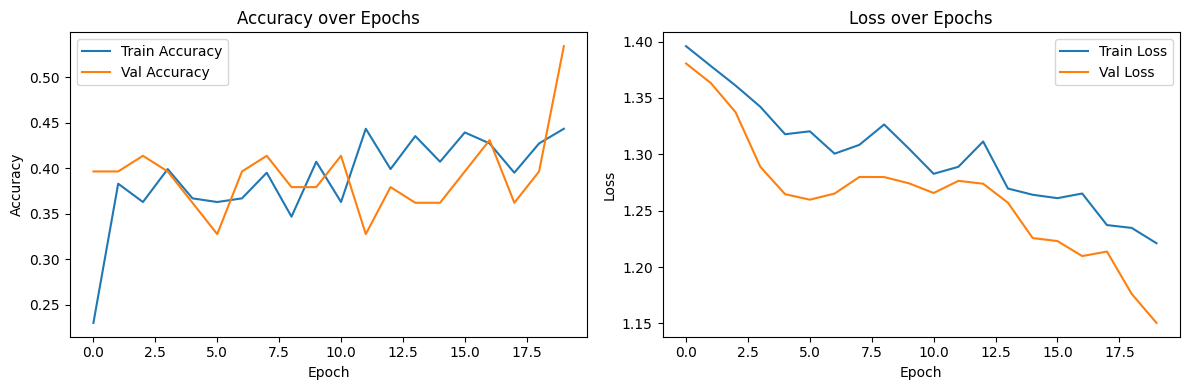

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy graph
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss graph
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()